# Homework 1 for MSDM 5054

Author: LAN, Tianwei 藍天蔚<br>
ID: 21230969<br>
Email: tlanaa@connect.ust.hk

## Problem 1:  Basic Knowledge

### 1.  "Overfitting occurs only when training error is zero." Is the claim True or Wrong? Explain!
Wrong. <br>
Training error does not have to be exactly zero for overfitting to occur. It usually happens when the model learns the training data too well, including noise and outliers. A model can overfit even if the training error is slightly above zero, especially in noisy or complex datasets. What matters is the gap between training and test error.

### 2. When $K$ increases, does the variance of KNN decrease or increase? Explain!
Decrease.<br>
With a small K, the KNN estimate is based on only handful neighbors, so any tiny perturbation can swing the prediction wildly; the model thus exhibits high variance and low bias. As K grows, the forecast is averaged over more points, diluting the influence of isolated anomalies; the prediction stabilizes, variance drops, and bias begins to rise.

### 3. Consider classification problem with the response variable $Y$ taking possible values from ${1,…,K}$ and denote $q_j(a)=P(Y=j∣X=a),∀j=1,…,K$ the probability that $Y=j$ given $X=a$. What is the expected misclassification error of the Bayes Classifier? You can use $p(a)$ to represent the probability density function of $X$.

The Bayesian classifier selects the category with the largest posterior probability when the feature is $x$:
$$\hat{y} =arg \max_j q_j(x)$$
So the classification error probability given $X=x$ is 1 minus the correct probability:
$$P(error|X=x)=1-\max_j q_j(x)$$
The expected error rate is averaged over all possible features $x$ (also known as Total Probability Formula):
$$P(error) = \sum^{R} P(error|X=x)P(X=x)dx$$
$$ = \sum^{R} (1-\max_{j \in {1,2,..,K} } q_{j}(x))p(x)dx \qquad \text{(discrete)}$$
When $X$ is continuous:
$$P(error) = \int_{R} P(error|X=x)P(X=x)dx$$
$$=\int_{R} (1-\max_{j \in {1,2,..,K} } q_{j}(x))p(x)dx \qquad \text{(continuous)}$$

### 4. Show that the sum of residuals in simple linear regression is zero. How about in multiple linear regression?
When doing Simple Linear Regression, we often use OLS method to estimate the parameters $\beta_1,\beta_0$. The core idea of OLS is to minimize SSE:
$$\min_{\beta_1,\beta_0} \sum_{i=1}^{n} (y_i-\beta_1 x_i-\beta_0)^2$$
Take the partial derivative of $\beta_0 $ and set it to 0:
$$\frac{\partial}{\partial \beta_0}\sum_{i=1}^{n} (y_i-\beta_1 x_i-\beta_0)^2 = -2\sum_{i=1}^{n} (y_i-\beta_1 x_i-\beta_0) = 0$$
which is excatly the sum of residuals (following abbreviated as $RS$):
$$RS=\sum_{i=1}^{n} \hat{\epsilon_i} = \sum_{i=1}^{n} (y_i-\beta_1 x_i-\beta_0) = 0$$
When doing Multiple Linear Regression, we pay no attention to how many $\beta_i$ s are there in the formula. As long as **there is $\beta_0$ and OLS is used**, the partial derivative of $\beta_0$ must be taken and set to 0, which results in $RS$ being 0. If the model does not have a constant term, or does not use OLS (such as WLS, Lasso, GLM, etc., which do not use SSE minimization as a criterion), then $RS$ cannot be guaranteed to be 0.

### 5. Given two linear models with the same number of parameters, can we use R square to compare the performance of the two models, or must we use the adjusted R square? Explain!.
The definition of $R^2$ is:
$$R^2 = 1-\frac{SSE}{SST}=1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y}_i)^2}$$
The objective of OLS is to minimize SSE. When the model expands from $p$ to $p+1$ predictors, the fitting space becomes larger; the old space is a subset of the new one, so the new minimal SSE cannot be larger than before. Because SSE is monotonically non-increasing, $R^2$ consequently increases. So there is adjusted-$R^2$:
$$R^2_{adj}=1-\frac{SSE/(n-p-1)}{SST/(n-1)}$$
$$ n\text{: number of samples}$$
$$ p\text{: number of predictors}$$
which removes the impact of predictor count, so it’s only necessary when comparing models with different numbers of parameters; for two linear models with the same number, plain $R^2$ suffices.


### 6. Explain the advantage and disadvantage of linear regression and KNN regression.

Linear Regression

PROS:<br>
1.Simple, interpretable and intuitive, the coefficients show marginal effects.<br>
2.Closed-form solution, almost free to train and fast to predict.<br>
3.Rich theory: hypothesis tests, confidence intervals, regularization, etc.<br>

CONS:<br>
1.Can only model linear or linearizable relationships, can't handle nonlinear patterns.<br>
2.Sensitive to noise and outliers.<br>
3.Relies on strong assumptions of linearity, homoscedasticity, independent errors.<br>

KNN Regression:

PROS:<br>
1.Non-parametric, don't need assumptions, adapts to arbitrarily complex nonlinear shapes.<br>
2.Easy to implement; no explicit training, new data are instantly incorporated.<br>

CONS:<br>
1.Sensitive to feature scale, need standardization and normalization<br>
2.Sensitive to K: small K chases noise; large K oversmooths and makes the model sluggish.<br>
3.Distance metrics break down in high dimensions, dimensionality reduction is required.<br>
4.No explicit model, thus less interpretable and can't measure variable importance<br>

## Problem 2: Investigation of Life Expectancy

Gen AI is used to help with coding in question 1, 4 and 5.

### 1. Report the summary of the linear model. What are the predicting variables actually a ecting the life expectancy? Justify your answer based on the outputs of linear regression model.

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Life Expectancy Data.csv")

# data cleaning: missing values ​​are filled with medians
num_cols = df.select_dtypes(include='number').columns
df = df[num_cols].copy()
df = df.dropna(subset=['Life expectancy '])
y = df['Life expectancy '].reset_index(drop=True)
X = df.drop(columns=['Life expectancy ']).fillna(df.median())

# standardize for performance comparison
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# fitting model
X_const = sm.add_constant(X_scaled)
model = sm.OLS(y, X_const).fit()
print(model.summary())

# pick the significant predictors（p<0.05 and with +/- coefficient）
sig = (model.pvalues[model.pvalues < 0.05]
       .drop('const', errors='ignore')
       .sort_values())
coef_ord = model.params[sig.index].sort_values(key=abs, ascending=False)

print("\n===== Significant Predictors (by |coef|) =====")
for v in coef_ord.index:
    print(f"{v:25s}  coef={model.params[v]:7.3f}   p={model.pvalues[v]:.4f}")

                            OLS Regression Results                            
Dep. Variable:       Life expectancy    R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     689.3
Date:                Tue, 16 Sep 2025   Prob (F-statistic):               0.00
Time:                        19:11:21   Log-Likelihood:                -8256.5
No. Observations:                2928   AIC:                         1.655e+04
Df Residuals:                    2908   BIC:                         1.667e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

Two abnormally large coefficients are observed, presumably due to multicollinearity between "infant deaths" and "under-five deaths". After testing, the performance of the multivariate linear regression model using the two indicators alone is similar, so we retain "infant deaths".

In [48]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Life Expectancy Data.csv")

# data cleaning: missing values ​​are filled with medians
num_cols = df.select_dtypes(include='number').columns
df = df[num_cols].copy()
df = df.dropna(subset=['Life expectancy '])
y = df['Life expectancy '].reset_index(drop=True)
X = df.drop(columns=['Life expectancy ','under-five deaths ']).fillna(df.median())

# standardize for performance comparison
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# fitting model
X_const = sm.add_constant(X_scaled)
model = sm.OLS(y, X_const).fit()
print(model.summary())

# pick the significant predictors（p<0.05 and with +/- coefficient）
sig = (model.pvalues[model.pvalues < 0.05]
       .drop('const', errors='ignore')
       .sort_values())
coef_ord = model.params[sig.index].sort_values(key=abs, ascending=False)

print("\n===== Significant Predictors (by |coef|) =====")
for v in coef_ord.index:
    print(f"{v:25s}  coef={model.params[v]:7.3f}   p={model.pvalues[v]:.4f}")

                            OLS Regression Results                            
Dep. Variable:       Life expectancy    R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     686.7
Date:                Tue, 16 Sep 2025   Prob (F-statistic):               0.00
Time:                        19:15:25   Log-Likelihood:                -8325.8
No. Observations:                2928   AIC:                         1.669e+04
Df Residuals:                    2909   BIC:                         1.680e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

Model report is above. adjusted-$R^2=0.808$ shows the effectiveness of the model with 19 predictors

Top significant drivers:<br>
Negative:<br>
1.Adult Mortality (–2.58)<br>
2.HIV/AIDS (–2.47)<br>

Positive:<br>
1.Schooling (+2.35)<br>
2.Income composition (+1.304)<br>
3.Diphtheria (+1.132)<br>

### 2. Construct the 95% confidence intervals for the coeficient of Adult Mortality and HIV/AIDS. Are you condent that these predictors have negative impact on the life expectancy? Explain why.

The 95% confidence intervals were given above.

According to the regression output:<br>
Adult Mortality: coef = –2.520 95% CI ≈ [–2.714, –2.325] (all < 0)<br>
HIV/AIDS: coef = –2.408 95% CI ≈ [–2.585, –2.231] (all < 0)<br>

Both intervals do not include 0 and are completely on the negative axis. Have sufficient statistical confidence that these two predictors do have a negative impact on life expectancy.

### 3. Construct the 97% condence intervals for the coe cient of Schooling and Alcohol . Explain how these predictors impact the life expectancy.

In [33]:
from scipy.stats import t

vars_97 = ['Adult Mortality', ' HIV/AIDS']
print('97 % Confidence Intervals')
for v in vars_97:
    coef = model.params[v]
    se   = model.bse[v]
    half_width = se * t.ppf(1 - 0.015, model.df_resid)
    print(f'{v:25s}: {coef:7.3f}  [{coef - half_width:7.3f}, {coef + half_width:7.3f}]')

97 % Confidence Intervals
Adult Mortality          :  -2.577  [ -2.797,  -2.357]
 HIV/AIDS                :  -2.467  [ -2.667,  -2.266]


Both predictors negatively impact life expectancy.

**Adult Mortality** (deaths at ages of 15–60) at high value means more productive population die early, shrinking average lifespan of the whole population.

**HIV/AIDS** weaken the immune system, leading to infections and even cancers, pulling life expectancy downward.

### 4. Based on the p-values, which are the top-seven most influential predictors? Use these predictors to fit a smaller model and report the summary

The top 7 most influential predictors are (all $p<0.05$):

1.Adult Mortality (–2.58)<br>
2.HIV/AIDS (–2.47)<br>
3.Schooling (+2.35)<br>
4.Income composition (+1.30)<br>
5.Diphtheria (+1.13)<br>
6.BMI (+0.88)<br>
7.Polio (+0.75)<br>

In [63]:
top7 = ['Adult Mortality',' HIV/AIDS', 'Schooling', 'Income composition of resources', 'Diphtheria ',' BMI ', 'Polio']
X7 = df[top7].fillna(df.median()).reset_index(drop=True)

scaler7 = StandardScaler().fit(X7)
X7_scaled = pd.DataFrame(scaler7.transform(X7), columns=top7)

X7_const = sm.add_constant(X7_scaled)
model7 = sm.OLS(y, X7_const).fit()
print(model7.summary())

                            OLS Regression Results                            
Dep. Variable:       Life expectancy    R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     1647.
Date:                Wed, 17 Sep 2025   Prob (F-statistic):               0.00
Time:                        00:39:49   Log-Likelihood:                -8412.2
No. Observations:                2928   AIC:                         1.684e+04
Df Residuals:                    2920   BIC:                         1.689e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

### 5. Use the smaller model to predict the life expectancy if a new observation is given with *Year=2008, Status=Developed, Adult Mortality=125, infant deaths=94, Alcohol=4.1, percentage expenditure=100, Hepatitis B=20, Measles=13, BMI=55, under-five deaths=2, Polio=12, Total expenditure=5.9, Diphtheria=12, HIV/AIDS=0.5, GDP=5892, Population=134106, Income composition of resources=0.9, Schooling=18*. Report the 99% condence interval for your prediction.

In [67]:
#['Adult Mortality',' HIV/AIDS', 'Schooling', 'Income composition of resources', 'Diphtheria ',' BMI ', 'Polio']
raw = pd.DataFrame([[125, 0.5, 18, 0.9, 12, 55, 12]], columns=top7)
X_new_scaled = pd.DataFrame(scaler7.transform(raw), columns=top7)
X_new = X_new_scaled.copy()
X_new.insert(0, 'const', 1.0)
y_pred = model7.predict(X_new)
print('Predicted Life Expectancy = {:.1f} years'.format(y_pred.iloc[0]))

Predicted Life Expectancy = 73.3 years


### 6. Use AIC to compare the full model and the smaller model.

AIC encourages good data fitting but tries to avoid overfitting. Smaller AIC is better

Full model's AIC  $= 1.669 \times 10^4$ <br>
Small model's AIC $= 1.684 \times 10^4$

The AIC difference between the two models is approximately 150, indicating that the full model still significantly outperforms the small one.

##  Problem 3: Implement KNN regression

### 1. The MSE and the corresponding running time on test data for differnt values of *K*. Report the best value of *K*.

In [21]:
import pandas as pd
import numpy as np
import time

# Read in the training and test datasets
df_tr = pd.read_csv('boston_housing_train.csv')
df_te = pd.read_csv('boston_housing_test.csv')

# Set predictors and dependent variables
pred_cols = df_tr.columns.drop("medv")
X_tr = df_tr[pred_cols].values
y_tr = df_tr["medv"].values
X_te = df_te[pred_cols].values
y_te = df_te["medv"].values

# Handwritten KNN function
def knn_regress(X_tr, y_tr, X_te, k=5):
    preds = []
    for x in X_te:
        dist = np.sqrt(np.sum((X_tr - x) ** 2, axis=1)) # Calculate Euclidean distance 
        idx  = np.argsort(dist)[:k] # Get the nearest K indexs
        preds.append(np.mean(y_tr[idx])) # Find the mean of these K points as the result
    return np.array(preds)

# output test result
results = []
for k in range(1,21):
    t0 = time.time()
    y_pred = knn_regress(X_tr, y_tr, X_te, k)
    elapsed = time.time() - t0
    mse = np.mean((y_te - y_pred) ** 2)
    results.append({'K': k, 'MSE': mse, 'Time(s)': elapsed})

# Output the best K
df_res = pd.DataFrame(results)
best_k = df_res.loc[df_res['MSE'].idxmin(), 'K']
print(df_res)
print(f'\nBest K (lowest MSE): {best_k}')

     K        MSE   Time(s)
0    1  44.517087  0.082549
1    2  46.055906  0.009136
2    3  41.523237  0.010062
3    4  40.887918  0.009569
4    5  42.241124  0.009636
5    6  43.889407  0.009860
6    7  43.985068  0.008009
7    8  42.830324  0.009001
8    9  44.043440  0.008996
9   10  45.614328  0.009299
10  11  45.783521  0.004049
11  12  45.878355  0.012064
12  13  45.765006  0.005046
13  14  46.513860  0.011663
14  15  46.534874  0.005990
15  16  48.189610  0.013447
16  17  49.132719  0.009001
17  18  48.926461  0.005393
18  19  50.128823  0.011264
19  20  51.090041  0.008086

Best K (lowest MSE): 4


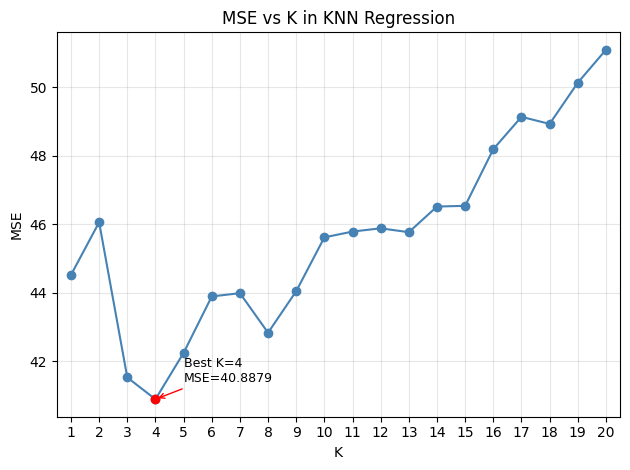

In [22]:
# Extra:Plot the MSE-K line chart
import matplotlib.pyplot as plt 

plt.plot(df_res['K'], df_res['MSE'], marker='o', linestyle='-', color='steelblue')
    
idx_min = df_res['MSE'].idxmin()
best_k  = df_res.loc[idx_min, 'K']
best_mse= df_res.loc[idx_min, 'MSE']

plt.scatter(best_k, best_mse, color='red', zorder=5)
plt.annotate(f'Best K={best_k}\nMSE={best_mse:.4f}',
             xy=(best_k, best_mse),
             xytext=(best_k+1, best_mse+0.5),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, ha='left')
    
plt.xlabel('K')
plt.ylabel('MSE')
plt.title('MSE vs K in KNN Regression')
plt.xticks(range(1, 21))
plt.xlim(0.5, 20.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Standardize the predictor variables (excluding the response variable) in both training and test data. Report The MSE and the corresponding running time on test data for different values of *K*. Report the bset value of *K*.

In [23]:
import pandas as pd
import numpy as np
import time

# Read in the training and test datasets
df_tr = pd.read_csv('boston_housing_train.csv')
df_te = pd.read_csv('boston_housing_test.csv')

# Set standardized predictors and dependent variables
pred_cols = df_tr.columns.drop("medv")
mean = df_tr[pred_cols].mean()
std  = df_tr[pred_cols].std()
X_tr = (df_tr[pred_cols] - mean) / std
X_te = (df_te[pred_cols] - mean) / std
X_tr = X_tr.values
X_te = X_te.values
y_tr = df_tr["medv"].values
y_te = df_te["medv"].values

# Handwritten KNN function
def knn_regress(X_tr, y_tr, X_te, k=5):
    preds = []
    for x in X_te:
        dist = np.sqrt(np.sum((X_tr - x) ** 2, axis=1)) # Calculate Euclidean distance 
        idx  = np.argsort(dist)[:k] # Get the nearest K indexs
        preds.append(np.mean(y_tr[idx])) # Find the mean of these K points as the result
    return np.array(preds)

# output test result
results = []
for k in range(1,21):
    t0 = time.time()
    y_pred = knn_regress(X_tr, y_tr, X_te, k)
    elapsed = time.time() - t0
    mse = np.mean((y_te - y_pred) ** 2)
    results.append({'K': k, 'MSE': mse, 'Time(s)': elapsed})

# Output the best K
df_res = pd.DataFrame(results)
best_k = df_res.loc[df_res['MSE'].idxmin(), 'K']
print(df_res)
print(f'\nBest K (lowest MSE): {best_k}')

     K        MSE   Time(s)
0    1  25.469291  0.007281
1    2  16.777579  0.013038
2    3  19.734873  0.004928
3    4  20.019941  0.009444
4    5  21.226831  0.009602
5    6  22.255448  0.011873
6    7  21.654662  0.009001
7    8  20.868349  0.008011
8    9  21.036780  0.008634
9   10  20.508135  0.004835
10  11  20.584193  0.010289
11  12  20.443278  0.010776
12  13  20.855490  0.010184
13  14  21.566416  0.005015
14  15  21.723297  0.010163
15  16  22.093315  0.010147
16  17  22.663073  0.005110
17  18  23.372526  0.010145
18  19  24.198553  0.010428
19  20  24.453894  0.010525

Best K (lowest MSE): 2


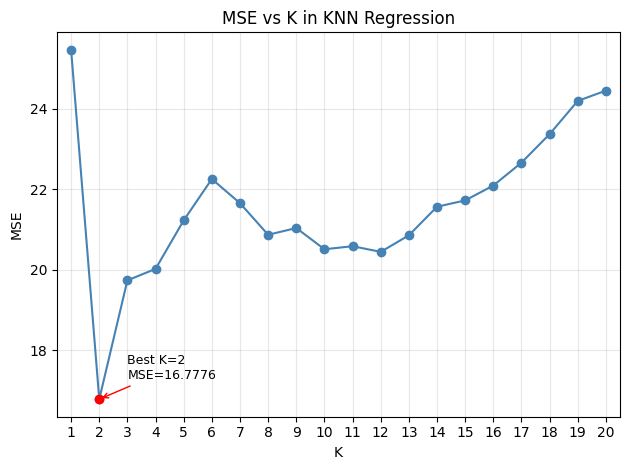

In [24]:
# Extra:Plot the MSE-K line chart
import matplotlib.pyplot as plt 

plt.plot(df_res['K'], df_res['MSE'], marker='o', linestyle='-', color='steelblue')
    
idx_min = df_res['MSE'].idxmin()
best_k  = df_res.loc[idx_min, 'K']
best_mse= df_res.loc[idx_min, 'MSE']

plt.scatter(best_k, best_mse, color='red', zorder=5)
plt.annotate(f'Best K={best_k}\nMSE={best_mse:.4f}',
             xy=(best_k, best_mse),
             xytext=(best_k+1, best_mse+0.5),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, ha='left')
    
plt.xlabel('K')
plt.ylabel('MSE')
plt.title('MSE vs K in KNN Regression')
plt.xticks(range(1, 21))
plt.xlim(0.5, 20.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Does standardization improve the proformance?

On this dataset, standardization sharply boosts KNN regression: MSE drops by 60 % and optimal K falls from 4 to 2, as equalized scales yield more sensible distances and less need for large-K smoothing.